# Analyse mechanism results

Read-only orchestrator over the result tables (Volt-VAr proxy, Volt-Watt proxy, response observability) via `result_views.py` and `result_plots.py`. 

In [13]:
from __future__ import annotations

import dataclasses
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'src' / 'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ausgrid_analysis.config import load_config
from ausgrid_analysis.mechanism_config import load_mechanism_config
from ausgrid_analysis import result_plots as rp
from ausgrid_analysis import result_views as rv

CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
config = load_config(CONFIG_PATH, check_inputs=True)
mechanism_der_inferred = load_mechanism_config(CONFIG_PATH)
mechanism_all_phases = dataclasses.replace(mechanism_der_inferred, phase_scope_basis='all_phases').validate()
mechanism_solar_proxy = dataclasses.replace(mechanism_der_inferred, capacity_basis='solar_capacity_kw_proxy').validate()
mechanism_p99_proxy = dataclasses.replace(mechanism_der_inferred, capacity_basis='p99_net_export_proxy').validate()
TRACKS = {
    'der_inferred': mechanism_der_inferred,
    'all_phases': mechanism_all_phases,
    'solar_capacity_kw_proxy': mechanism_solar_proxy,
    'p99_net_export_proxy': mechanism_p99_proxy,
}
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Stage 0: purpose, guardrails and source inventory

Lists every result file for both tracks (existence, size, row count, methodology id) and pulls the reconciled methodology/provenance context for each. 

`result_context` raises if a table's own methodology/provenance columns are internally mixed. 

The one expected cross-table difference `response_observability`'s methodology id not matching an `all_phases` curve-table run, because that table is never rebuilt per track. 
Is reported as an explicit flag rather than an error.

In [14]:
SAMPLE_MONTH = '2025-04'
SAMPLE_SITE_BUCKET = 0
sample_scope = config.scope(SAMPLE_MONTH, SAMPLE_SITE_BUCKET)
full_scope = config.scope(None, None)

contexts = {}
for track_name, mechanism in TRACKS.items():
    print(f'--- {track_name} ---')
    inventory = rv.result_inventory(config, full_scope, mechanism=mechanism)
    display(inventory)
    context = rv.result_context(config, full_scope, mechanism=mechanism)
    contexts[track_name] = context
    display(pd.Series(context, name='value').to_frame())
    assert context['formal_inverter_conformance_assessable'] is False, (
        f'{track_name}: formal_inverter_conformance_assessable must stay False -- '
        'this notebook never claims formal conformance.'
    )
    existing = inventory.loc[inventory['exists'], 'distinct_methodology_ids']
    assert (existing <= 1).all(), (
        f'{track_name}: a result file contains more than one methodology_id -- stop and investigate.'
    )

print()
print('response_observability_methodology_matches_curve_tables per track:')
for track_name, context in contexts.items():
    print(f"  {track_name}: {context['response_observability_methodology_matches_curve_tables']}")

--- der_inferred ---


,table,path,exists,size_bytes,modified_utc,row_count,distinct_methodology_ids,methodology_id
0,voltvar_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1092884,2026-08-03T04:40:34.634905+00:00,122318,1,net_meter_proxy__voltage_avg__capacity_s_rated...
1,voltwatt_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1068565,2026-08-03T04:40:44.758383+00:00,122318,1,net_meter_proxy__voltage_avg__capacity_s_rated...
2,response_observability,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,359822,2026-08-03T04:41:04.036106+00:00,32494,1,net_meter_proxy__voltage_avg__capacity_s_rated...


,value
measurement_basis,net_meter_proxy
voltage_measurement_location,revenue_meter
active_sign_review_state,empirically_supported_pending_provider_confirm...
formal_inverter_conformance_assessable,False
reactive_sign_review_state,empirically_supported_pending_provider_confirm...
voltage_basis,mean_inferred_der_phase_revenue_meter_voltage
capacity_basis,s_rated_kva
methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_matches_curve_tables,True


--- all_phases ---


,table,path,exists,size_bytes,modified_utc,row_count,distinct_methodology_ids,methodology_id
0,voltvar_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,2053990,2026-08-03T04:41:50.786726+00:00,236277,1,net_meter_proxy__voltage_avg__phase_all_phases...
1,voltwatt_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,2022134,2026-08-03T04:42:01.022982+00:00,236277,1,net_meter_proxy__voltage_avg__phase_all_phases...
2,response_observability,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,359822,2026-08-03T04:41:04.036106+00:00,32494,1,net_meter_proxy__voltage_avg__capacity_s_rated...


...

,value
measurement_basis,net_meter_proxy
voltage_measurement_location,revenue_meter
active_sign_review_state,empirically_supported_pending_provider_confirm...
formal_inverter_conformance_assessable,False
reactive_sign_review_state,empirically_supported_pending_provider_confirm...
voltage_basis,mean_inferred_der_phase_revenue_meter_voltage
capacity_basis,solar_capacity_kw_proxy
methodology_id,net_meter_proxy__voltage_avg__capacity_solar_c...
response_observability_methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_matches_curve_tables,False


--- p99_net_export_proxy ---


,table,path,exists,size_bytes,modified_utc,row_count,distinct_methodology_ids,methodology_id
0,voltvar_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1676834,2026-08-03T02:14:40.627799+00:00,122318,1,net_meter_proxy__voltage_avg__capacity_p99_net...
1,voltwatt_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1077351,2026-08-03T02:15:10.942085+00:00,122318,1,net_meter_proxy__voltage_avg__capacity_p99_net...
2,response_observability,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,359822,2026-08-03T04:41:04.036106+00:00,32494,1,net_meter_proxy__voltage_avg__capacity_s_rated...


,value
measurement_basis,net_meter_proxy
voltage_measurement_location,revenue_meter
active_sign_review_state,empirically_supported_pending_provider_confirm...
formal_inverter_conformance_assessable,False
reactive_sign_review_state,empirically_supported_pending_provider_confirm...
voltage_basis,mean_inferred_der_phase_revenue_meter_voltage
capacity_basis,p99_net_export_proxy
methodology_id,net_meter_proxy__voltage_avg__capacity_p99_net...
response_observability_methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_matches_curve_tables,False



response_observability_methodology_matches_curve_tables per track:
  der_inferred: True
  all_phases: False
  solar_capacity_kw_proxy: False
  p99_net_export_proxy: False


## Stage 1: deterministic-slice validation

Same April 2025 / bucket 0 sample scope Notebook 4 uses. Loads the sample
mechanism outputs Notebook 4 already built and validates every
`result_views.py` view reconciles back to its own source file before any
plotting happens.

In [15]:
sample_validation = {}
for track_name, mechanism in TRACKS.items():
    result = rv.validate_result_views(config, sample_scope, mechanism=mechanism)
    sample_validation[track_name] = result
    headline = {k: v for k, v in result.items() if k not in {'failures', 'checks'}}
    display(pd.Series(headline, name='value').to_frame())
    if result['failures']:
        display(result['failures'])
    assert result['status'] == 'pass', f'{track_name}: sample view reconciliation failed -- see failures above.'
print('Deterministic-slice view reconciliation passed for both tracks.')

,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,der_inferred


,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,all_phases


,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,der_inferred


,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,der_inferred


Deterministic-slice view reconciliation passed for both tracks.


## Stage 2: Volt-VAr denominator coverage (deterministic slice)

Sequential denominator precedence: a source interval is classified as the
first of `ineligible_site`, `missing_input`, `not_activated`,
`sign_unverified`, `capacity_unavailable`, `below_minimum_active_power` that
applies, else `assessable`. Every fraction below is of `n_source_intervals`.

C:\Users\z3553082\AppData\Local\Temp\ipykernel_33916\876228763.py:8: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


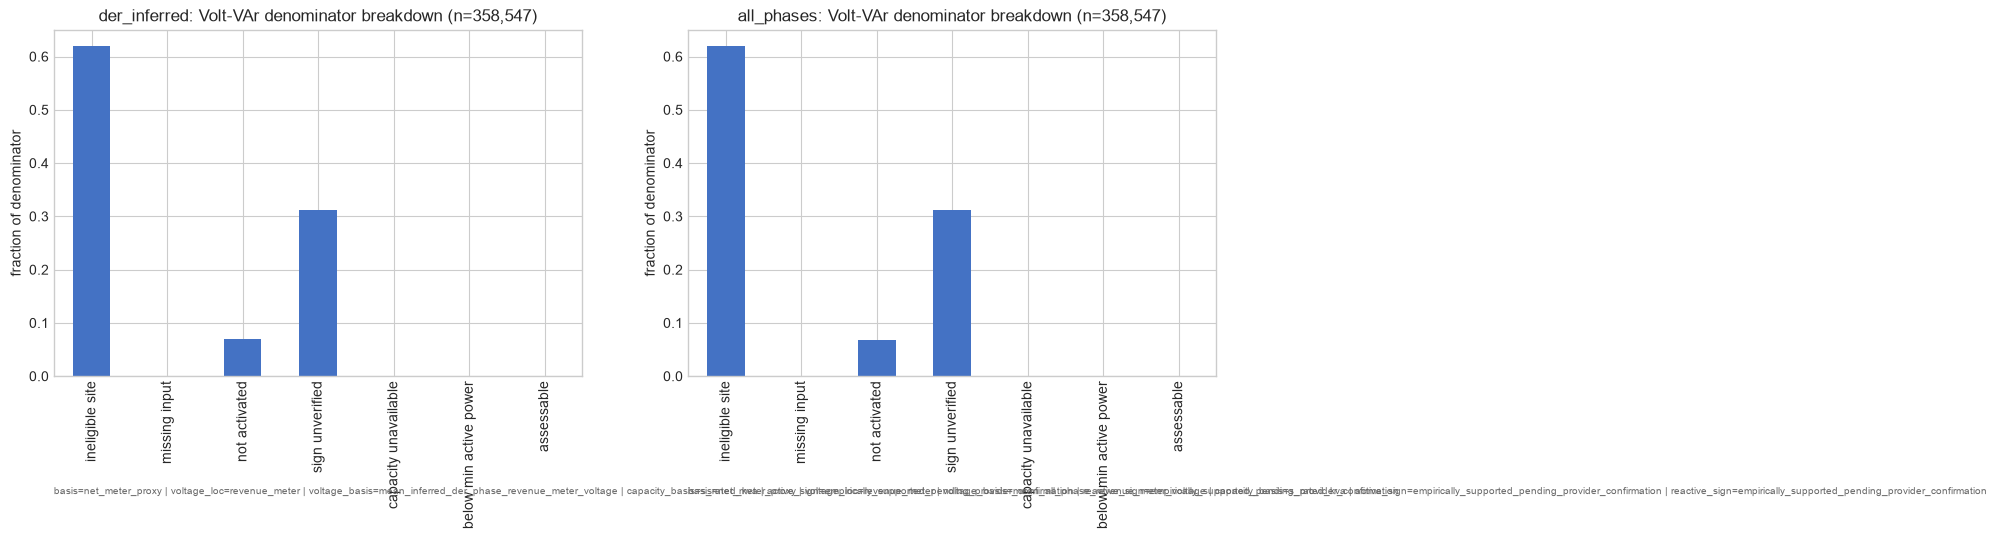

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sample_voltvar_denominator = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltvar_denominator_view(config, sample_scope, mechanism=mechanism)
    sample_voltvar_denominator[track_name] = frame
    rp.plot_denominator_breakdown(frame, mechanism_name='Volt-VAr', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
plt.tight_layout()
plt.show()

## Stage 3: Volt-VAr proxy statuses (deterministic slice)

Only meaningful if `n_assessable > 0`. With `s_rated_kva` unavailable for
every site today, `n_assessable` is expected to be 0 -- the panel below
shows that honestly rather than reporting a 0% conformance rate.

der_inferred: n_assessable = 0
all_phases: n_assessable = 0


C:\Users\z3553082\AppData\Local\Temp\ipykernel_33916\2328249234.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


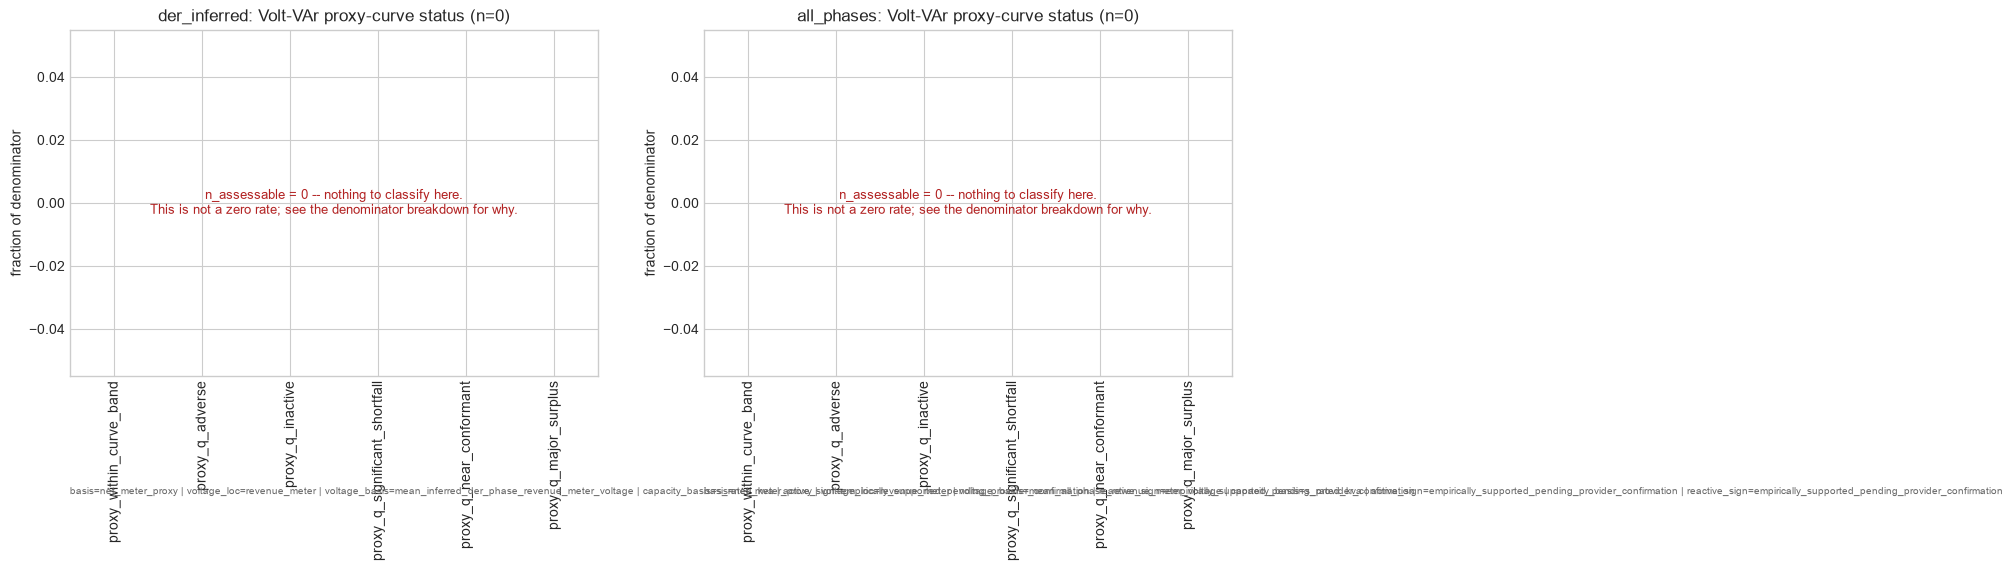

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sample_voltvar_status = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltvar_status_view(config, sample_scope, mechanism=mechanism, minimum_denominator=30)
    sample_voltvar_status[track_name] = frame
    rp.plot_status_breakdown(frame, mechanism_name='Volt-VAr', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
    n_assessable = int(frame['n_assessable'].iloc[0])
    print(f'{track_name}: n_assessable = {n_assessable:,}')
plt.tight_layout()
plt.show()

## Stage 4: Volt-Watt denominator coverage (deterministic slice)

`not_activated` (voltage at or below V1) and `not_exporting` (net export
`<= 0`) are different filters: a site can be exporting but below the
Volt-Watt activation voltage, or above it but net-importing at that instant.

C:\Users\z3553082\AppData\Local\Temp\ipykernel_33916\3962317222.py:8: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


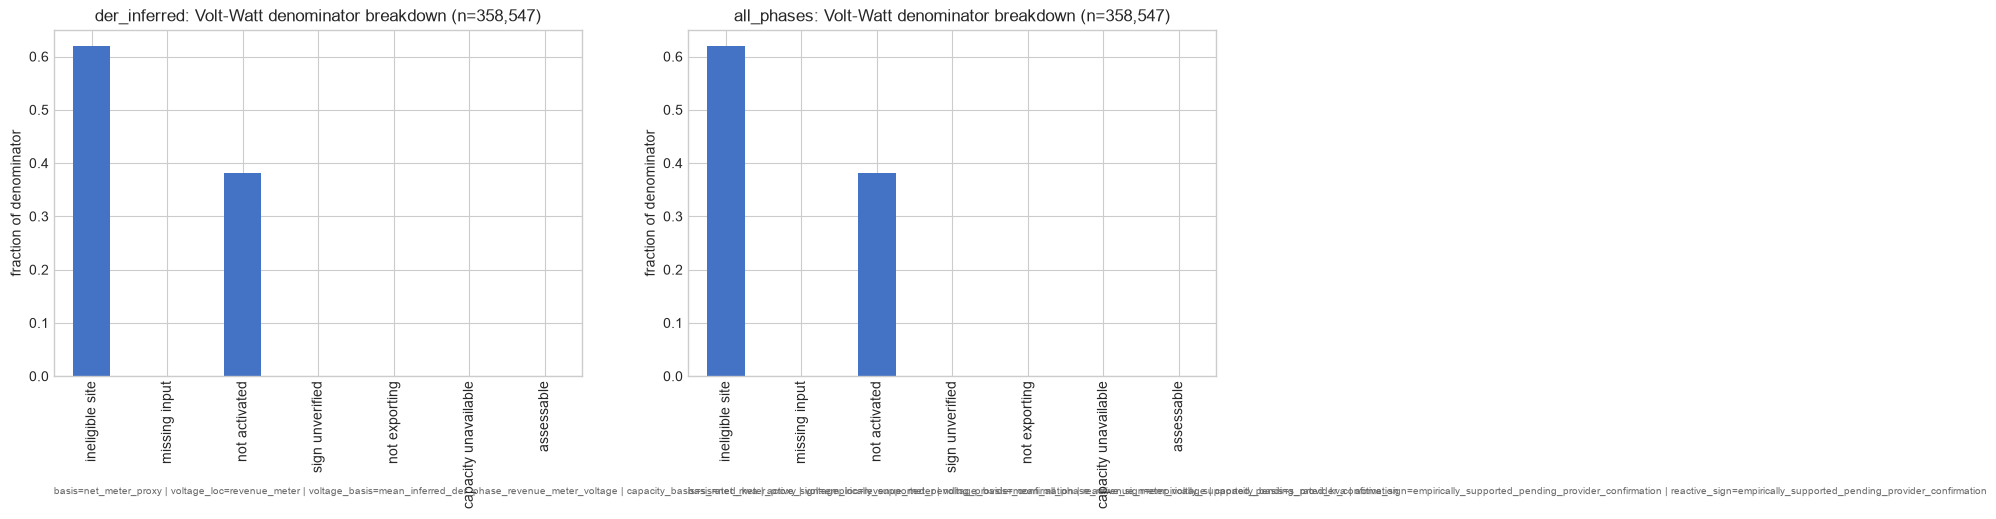

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sample_voltwatt_denominator = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltwatt_denominator_view(config, sample_scope, mechanism=mechanism)
    sample_voltwatt_denominator[track_name] = frame
    rp.plot_denominator_breakdown(frame, mechanism_name='Volt-Watt', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
plt.tight_layout()
plt.show()

## Stage 5: Volt-Watt proxy statuses (deterministic slice)

`proxy_does_not_exceed_curve_ceiling` is never conformance evidence --
household load can suppress net export below the ceiling regardless of
inverter behaviour.

der_inferred: n_assessable = 0
all_phases: n_assessable = 0


C:\Users\z3553082\AppData\Local\Temp\ipykernel_33916\4195422069.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


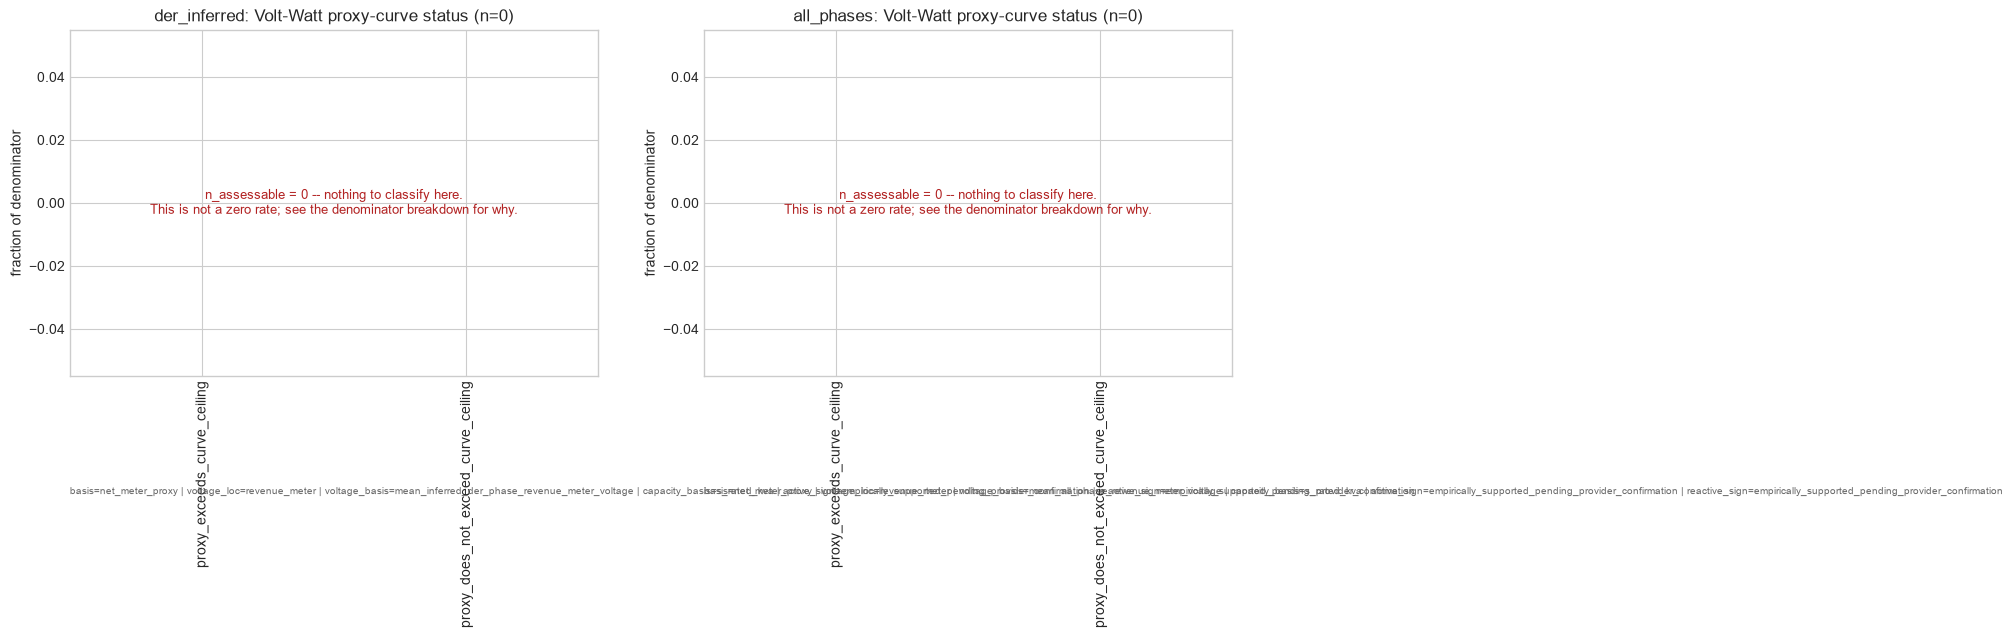

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sample_voltwatt_status = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltwatt_status_view(config, sample_scope, mechanism=mechanism)
    sample_voltwatt_status[track_name] = frame
    rp.plot_status_breakdown(frame, mechanism_name='Volt-Watt', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
    n_assessable = int(frame['n_assessable'].iloc[0])
    print(f'{track_name}: n_assessable = {n_assessable:,}')
plt.tight_layout()
plt.show()

## Stage 6: response observability (deterministic slice)

Volt-VAr and Volt-Watt observability are shown separately below; both
remain association/direction evidence only, never a causal or conformance
claim. `response_observability.parquet` is the single shared table -- it is
identical for both tracks (see the Stage 0 methodology check above), so it
is read once, using `mechanism_der_inferred` only for its review-state
labels.

,0
n_site_phase_months,89
n_voltvar_status_ineligible_site,42.0
n_voltvar_status_not_inferred_der_phase,9.0
n_voltvar_status_sign_unverified,38.0
n_voltvar_status_insufficient_excitation,0.0
n_voltvar_status_expected_direction_observed,0.0
n_voltvar_status_opposite_or_flat_direction_observed,0.0
n_voltwatt_status_ineligible_site,42.0
n_voltwatt_status_not_inferred_der_phase,9.0
n_voltwatt_status_sign_unverified,38.0


C:\Users\z3553082\AppData\Local\Temp\ipykernel_33916\3407070594.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


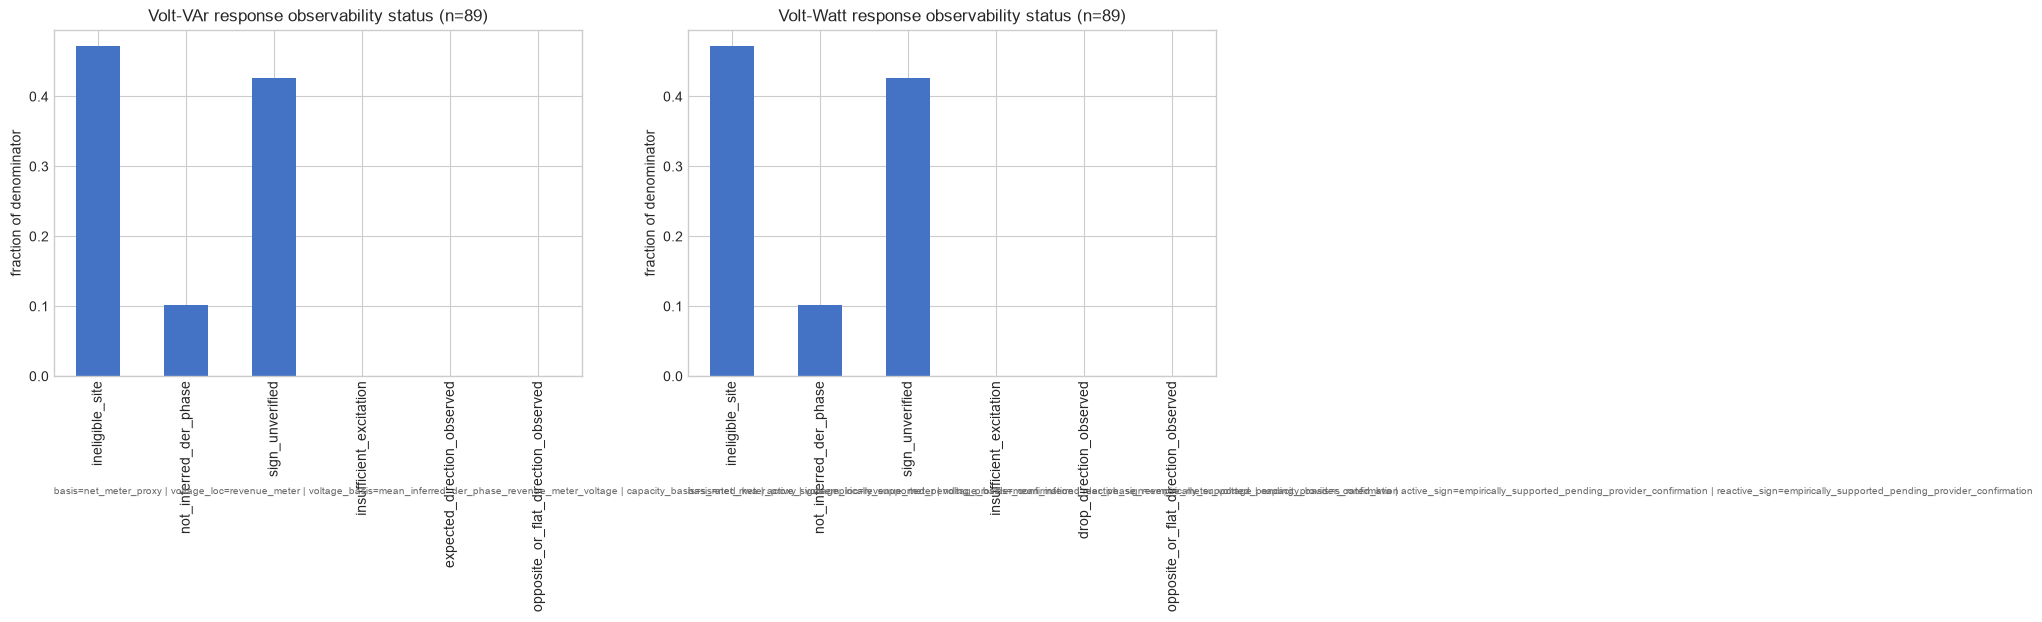

,0
n_voltvar_excited_intervals,269808.0
voltvar_slope_var_per_v_weighted_mean,22.385955
voltvar_voltage_correlation_mean,0.159267
voltvar_voltage_span_v_mean,8.269517
voltvar_minimum_voltage_v,240.009918
voltvar_maximum_voltage_v,252.985931
n_voltwatt_excited_export_intervals,0.0
voltwatt_slope_w_per_v_weighted_mean,NaN
voltwatt_voltage_correlation_mean,NaN
voltwatt_voltage_span_v_mean,NaN


In [8]:
sample_observability_status = rv.observability_status_view(config, sample_scope, mechanism=mechanism_der_inferred)
display(sample_observability_status.T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
rp.plot_observability_status(sample_observability_status, mechanism_name='Volt-VAr', context=contexts['der_inferred'], ax=axes[0])
rp.plot_observability_status(sample_observability_status, mechanism_name='Volt-Watt', context=contexts['der_inferred'], ax=axes[1])
plt.tight_layout()
plt.show()

sample_observability_metric = rv.observability_metric_view(
    config, sample_scope, mechanism=mechanism_der_inferred,
    minimum_excited_intervals=mechanism_der_inferred.minimum_response_intervals,
)
display(sample_observability_metric.T)

## Stage 7: sample gate

Re-asserts, for both tracks, that every view reconciles, dimensions are
valid, classifications never exceed their own denominator, and provenance is
internally consistent, before unlocking the full-results stages below.

In [9]:
for track_name, mechanism in TRACKS.items():
    result = rv.validate_result_views(config, sample_scope, mechanism=mechanism)
    assert result['status'] == 'pass', f"{track_name}: sample gate failed -- {result['failures']}"
    context = rv.result_context(config, sample_scope, mechanism=mechanism)
    assert context['formal_inverter_conformance_assessable'] is False
for track_name, frame in sample_voltvar_status.items():
    classified = sum(int(frame[c].iloc[0]) for c in rv.VOLTVAR_STATUS_COLUMNS)
    assert classified == int(frame['n_assessable'].iloc[0]), f'{track_name}: Volt-VAr classification exceeds n_assessable'
for track_name, frame in sample_voltwatt_status.items():
    classified = sum(int(frame[c].iloc[0]) for c in rv.VOLTWATT_STATUS_COLUMNS)
    assert classified == int(frame['n_assessable'].iloc[0]), f'{track_name}: Volt-Watt classification exceeds n_assessable'
print('Sample gate passed for both tracks -- proceeding to full-results analysis is safe.')

ValueError: active_sign_review_state disagrees between voltwatt_proxy_results ('empirically_supported_pending_provider_confirmation') and response_observability ('unverified') -- call result_context on one table/mechanism at a time rather than mixing.

## Stage 8: deliberate full-results analysis

The remaining stages read the full Notebook 4 outputs (not a sample). They
are still read-only -- no `build_*` call appears below -- but can be
computationally heavier, so they stay behind an explicit, deliberate opt-in
per the acceptance spec, mirroring Notebook 4's own full-run gate.

In [ ]:
FULL_ANALYSIS_CONFIRMATION = ''  # Change to: RUN FULL RESULTS ANALYSIS
assert sample_validation['der_inferred']['status'] == 'pass'
assert sample_validation['all_phases']['status'] == 'pass'
assert FULL_ANALYSIS_CONFIRMATION == 'RUN FULL RESULTS ANALYSIS', (
    "Review Stages 0-7 above, then set FULL_ANALYSIS_CONFIRMATION = 'RUN FULL RESULTS ANALYSIS'."
)
print('Full-results analysis unlocked:', full_scope.label)

## Stage 9: fleet, month, cohort and voltage views (full dataset)

For each independent track and each mechanism, this repeats Stages 2-6's
shapes against the full dataset: fleet totals, UTC-month coverage,
analysis-cohort comparison, and (for the curve tables) voltage-bin status.
Nothing here is blended across mechanisms or tracks into one score.

In [ ]:
full_fleet_totals = []
for mechanism_name, denominator_view in (
    ('Volt-VAr', rv.voltvar_denominator_view),
    ('Volt-Watt', rv.voltwatt_denominator_view),
):
    for track_name, mechanism in TRACKS.items():
        frame = denominator_view(config, full_scope, mechanism=mechanism)
        row = frame.iloc[0].to_dict()
        row['mechanism'] = mechanism_name
        row['phase_scope_basis'] = track_name
        full_fleet_totals.append(row)
full_fleet_totals = pd.DataFrame(full_fleet_totals).set_index(['mechanism', 'phase_scope_basis'])
display(full_fleet_totals[[c for c in full_fleet_totals.columns if c.startswith('n_') or c.endswith('_fraction_of_source')]])

In [ ]:
full_denominator_by_month = {}
full_denominator_by_cohort = {}
full_status_by_voltage_bin = {}

for mechanism_name, denominator_view, status_view in (
    ('Volt-VAr', rv.voltvar_denominator_view, rv.voltvar_status_view),
    ('Volt-Watt', rv.voltwatt_denominator_view, rv.voltwatt_status_view),
):
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    for col_index, (track_name, mechanism) in enumerate(TRACKS.items()):
        context = contexts[track_name]
        month_frame = denominator_view(config, full_scope, mechanism=mechanism, dimensions=('year_utc', 'month_utc'))
        rp.plot_monthly_coverage(month_frame, mechanism_name=mechanism_name, context=context, ax=axes[0, col_index])
        axes[0, col_index].set_title(f'{track_name}: ' + axes[0, col_index].get_title())

        cohort_frame = denominator_view(config, full_scope, mechanism=mechanism, dimensions=('analysis_cohort',))
        rp.plot_cohort_comparison(cohort_frame, mechanism_name=mechanism_name, context=context, ax=axes[1, col_index])
        axes[1, col_index].set_title(f'{track_name}: ' + axes[1, col_index].get_title())

        full_denominator_by_month[(mechanism_name, track_name)] = month_frame
        full_denominator_by_cohort[(mechanism_name, track_name)] = cohort_frame
    fig.suptitle(f'{mechanism_name}: full-dataset month and cohort coverage')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
    for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
        voltage_frame = status_view(config, full_scope, mechanism=mechanism, dimensions=('voltage_bin_lower_v',))
        rp.plot_voltage_bin_status(voltage_frame, mechanism_name=mechanism_name, context=contexts[track_name], ax=ax)
        ax.set_title(f'{track_name}: ' + ax.get_title())
        full_status_by_voltage_bin[(mechanism_name, track_name)] = voltage_frame
    plt.tight_layout()
    plt.show()

In [ ]:
full_observability_by_month = rv.observability_status_view(
    config, full_scope, mechanism=mechanism_der_inferred, dimensions=('year_utc', 'month_utc')
)
display(full_observability_by_month[['year_utc', 'month_utc', 'n_site_phase_months']])

full_observability_by_cohort = rv.observability_status_view(
    config, full_scope, mechanism=mechanism_der_inferred, dimensions=('analysis_cohort',)
)
display(full_observability_by_cohort)

## Stage 10 — site and phase explorer

Set `SELECTED_SERIAL` and `SELECTED_PHASE` to inspect a specific site or
phase. Both use aggregated views only -- no per-interval telemetry is ever
loaded into pandas here. Denominator and methodology context are shown next
to each panel so an unassessable site is never mistaken for a
poor-performing one.

In [ ]:
per_site_month_der_vv = rv.voltvar_denominator_view(
    config, full_scope, mechanism=mechanism_der_inferred, dimensions=('serial', 'year_utc', 'month_utc')
)
per_site_month_der_vw = rv.voltwatt_denominator_view(
    config, full_scope, mechanism=mechanism_der_inferred, dimensions=('serial', 'year_utc', 'month_utc')
)

SELECTED_SERIAL = str(
    per_site_month_der_vv.groupby('serial')['n_source_intervals'].sum().sort_values(ascending=False).index[0]
)  # edit to inspect a different site
print('Selected serial:', SELECTED_SERIAL)

fig = rp.plot_site_profile(per_site_month_der_vv, per_site_month_der_vw, SELECTED_SERIAL, context=contexts['der_inferred'])
plt.show()

In [ ]:
SELECTED_PHASE = 'A'  # edit to 'A', 'B' or 'C'

observability_by_phase = rv.observability_status_view(config, full_scope, mechanism=mechanism_der_inferred, dimensions=('phase',))
display(observability_by_phase)

observability_metric_by_phase = rv.observability_metric_view(config, full_scope, mechanism=mechanism_der_inferred, dimensions=('phase',))
display(observability_metric_by_phase[observability_metric_by_phase['phase'] == SELECTED_PHASE])

## Stage 11 — curtailment status

Only the explicit unavailable-gate-7 panel is rendered. No curtailment
energy, frequency, rate or blended score is computed anywhere in this
notebook.

In [ ]:
rp.plot_curtailment_unavailable()
plt.show()

## Stage 12 — final interpretation checklist

**Structurally validated** (Stages 0, 1, 7): both `phase_scope_basis`
tracks' Volt-VAr and Volt-Watt result files carry a single, internally
consistent `methodology_id`; every fleet-level `result_views.py` aggregate
reconciles exactly to its own source parquet; classification counts never
exceed their own `n_assessable`; `response_observability` is confirmed
identical across both tracks (it is the one shared, unnamespaced table).

**Observable** (Stage 6, 9): response-observability status and
slope/correlation evidence exist for both mechanisms, but every
`*_observability_status` row is currently `sign_unverified` (or
`ineligible_site` / `not_inferred_der_phase`) because
`active_sign_review_state` and `reactive_sign_review_state` remain
`unverified` in `analysis.toml`. This is association/direction evidence
only -- never a causal or conformance claim -- and it stays that way
regardless of `phase_scope_basis`, since the sign gate is a fleet-wide
config choice, not a phase-scope one.

**Unassessable** (Stages 2-5, 9): `n_assessable` is 0 for both Volt-VAr and
Volt-Watt, on both tracks, across the entire fleet, because verified
`s_rated_kva` is null for every site in this metadata extract. No magnitude
proxy-curve status has ever been computed against the true AS/NZS 4777.2
bands as a result -- this is not a 0% conformance/failure rate, it is a
missing-input rate. The denominator breakdowns in Stages 2, 4 and 9 attach
the exact number of intervals affected.

**Curtailment** (Stage 11): remains explicitly `unavailable — methodology
gate 7 unmet`. No number was computed or displayed.

**Next methodological decisions**, in the order they unblock further
analysis:

1. Ausgrid confirmation (or an internally defensible empirical review) of
   `active_export_sign` / `reactive_absorbing_sign`, recorded as a ready
   `active_sign_review_state` / `reactive_sign_review_state` in
   `analysis.toml`, then a full Notebook 4 rebuild -- this unlocks real
   observability-direction statuses in Stage 6/9 (both mechanisms still also
   need item 2 below before any magnitude proxy-curve status exists).
2. A verified `s_rated_kva` source (or an explicitly authorised,
   separately-named proxy/sensitivity capacity basis, which
   `mechanism_config.py` currently refuses to accept silently) -- this
   unlocks Volt-VAr and Volt-Watt magnitude/proxy-curve-status assessment.
3. A decision on which `phase_scope_basis` is the primary reported track
   for any future write-up, informed by how large the gap in Stage 9's
   side-by-side denominator tables turns out to be once (1) and (2) are
   resolved and real assessable rows exist to compare.
4. A validated load-PV decomposition and uncertainty-aware counterfactual
   (methodology gate 7), or an explicitly authorised sensitivity-only
   empirical-envelope method, before any curtailment figure is computed.

This notebook does not recommend a resolution to any of the four items
above -- that remains the user's decision, informed by what Stages 0-11
show is and is not currently supportable by the data.